expert1 196.0 628.0
expert2 5.65 724.0
saad 552 552
zhu 38.0 550.0
expert3 0.0 1236.0


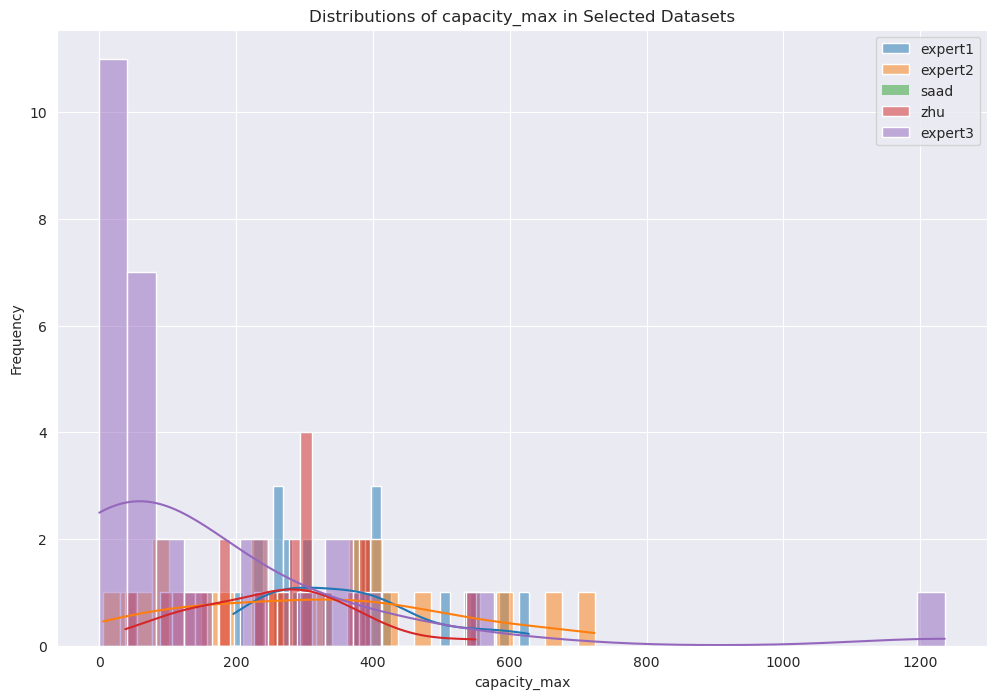

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the paths to the datasets
data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Plot the distributions of capacity_max

plt.figure(figsize=(12, 8))
for name, df in dfs.items():
    print(name, df['capacity_max'].min(), df['capacity_max'].max())
    sns.histplot(df['capacity_max'], kde=True, label=name, bins=30)

plt.title('Distributions of capacity_max in Selected Datasets')
plt.xlabel('capacity_max')
plt.ylabel('Frequency')
plt.legend()
plt.show()

,accuracy,baseline_mean_accuracy,baseline_median_accuracy,NDCG,baseline_mean_NDCG,baseline_median_NDCG,MAPE,baseline_mean_MAPE,baseline_median_MAPE,RMSE,baseline_mean_RMSE,baseline_median_RMSE,model,features,datasets
0,0.5667,0.5,0.5,0.8478,0.8519,0.8519,0.2744,0.2772,0.2742,110.0171,110.9341,109.2623,knn,custom,expert
1,0.5333,0.5,0.5,0.8296,0.8519,0.8519,0.2830,0.2772,0.2742,121.1118,110.9341,109.2623,xgboost,custom,expert
2,0.5333,0.5,0.5,0.8513,0.8519,0.8519,0.3152,0.2772,0.2742,138.7373,110.9341,109.2623,random_forest,custom,expert
3,0.6667,0.5,0.5,0.9104,0.8519,0.8519,0.2623,0.2772,0.2742,110.2572,110.9341,109.2623,lasso,custom,expert
4,0.5083,0.5,0.5,0.8588,0.8519,0.8519,0.3192,0.2772,0.2742,120.0415,110.9341,109.2623,knn,dft_custom,expert


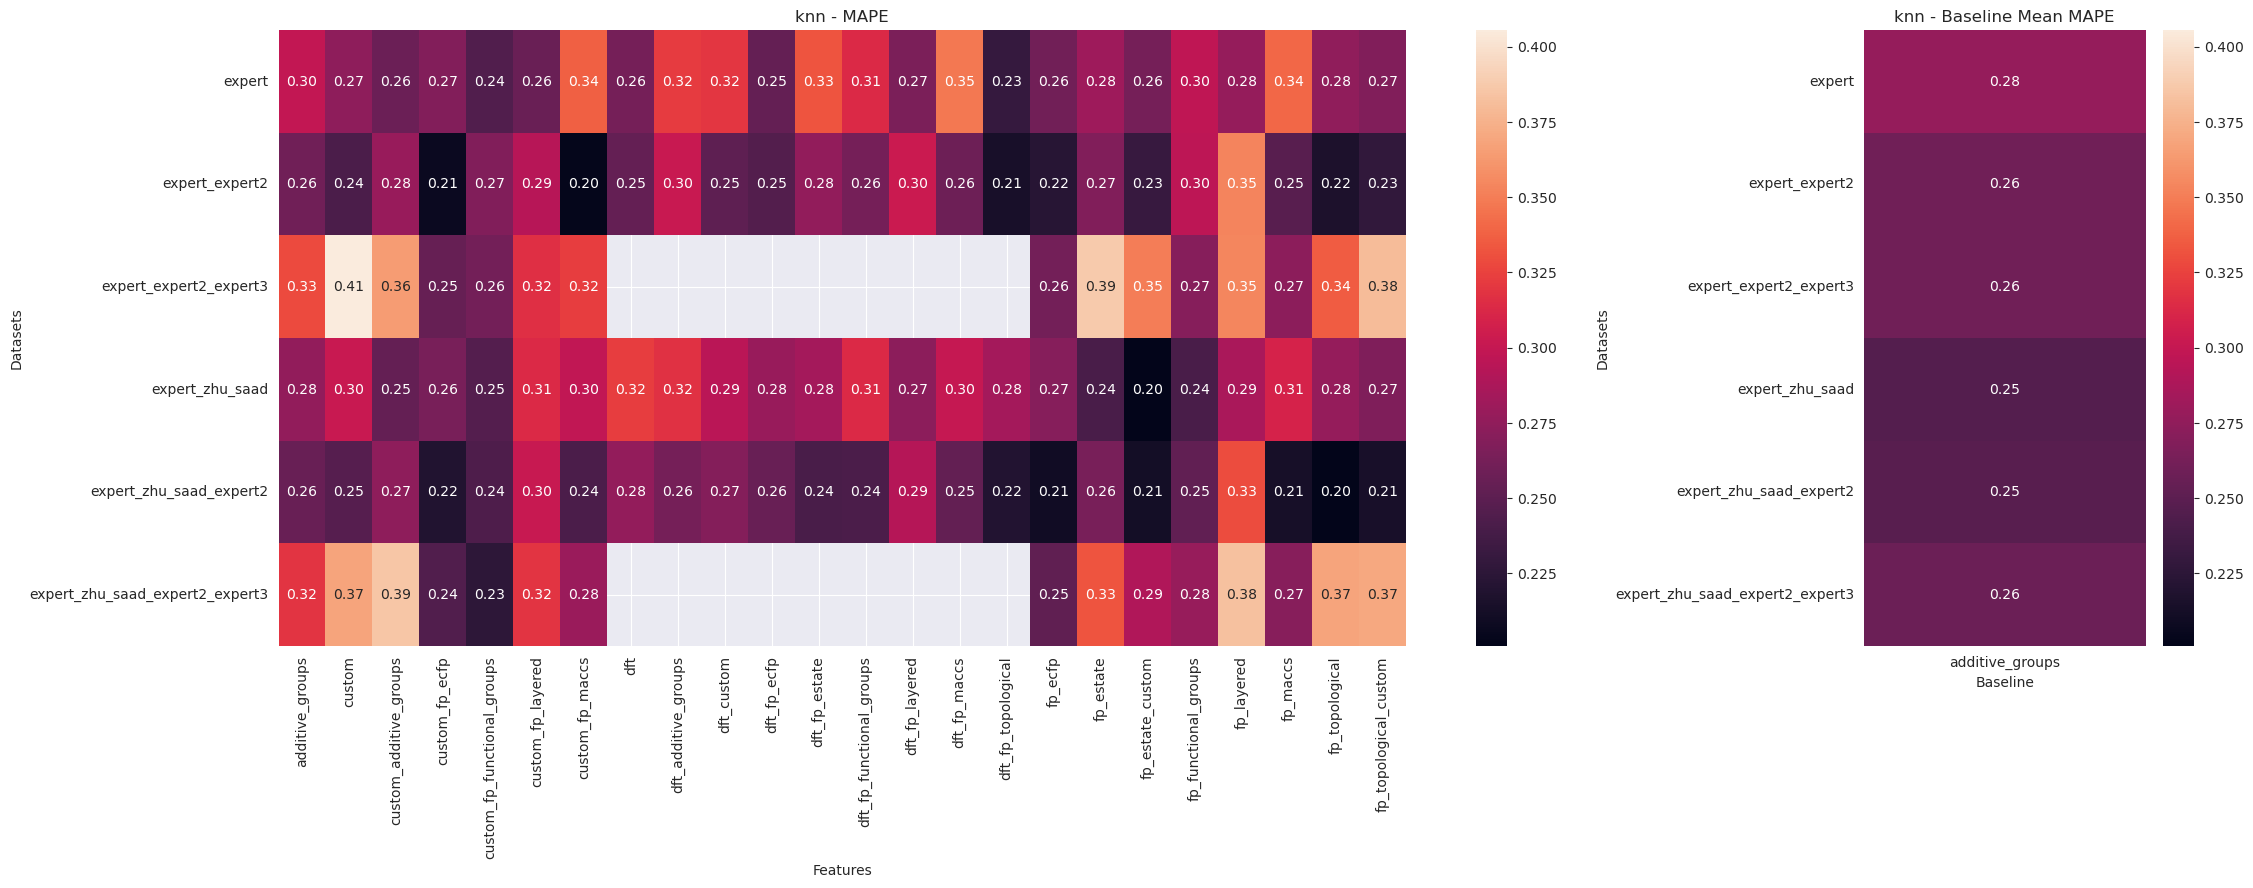

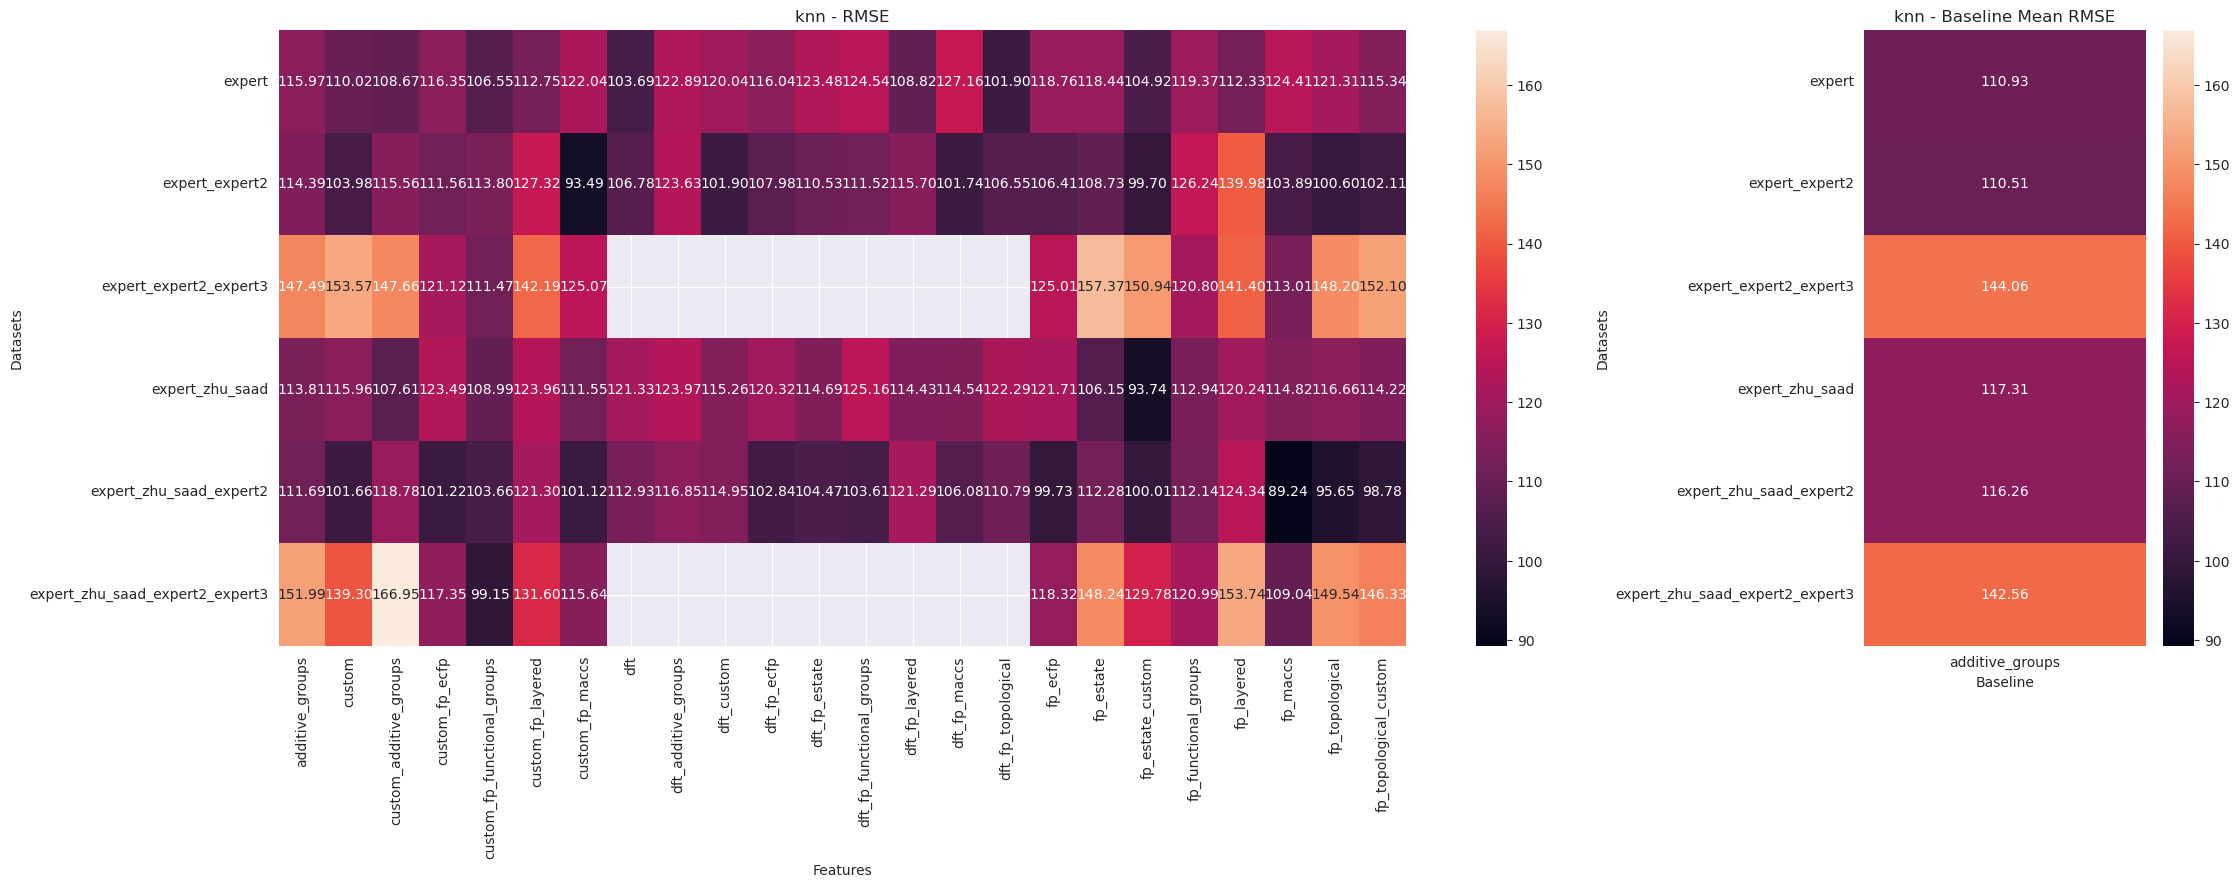

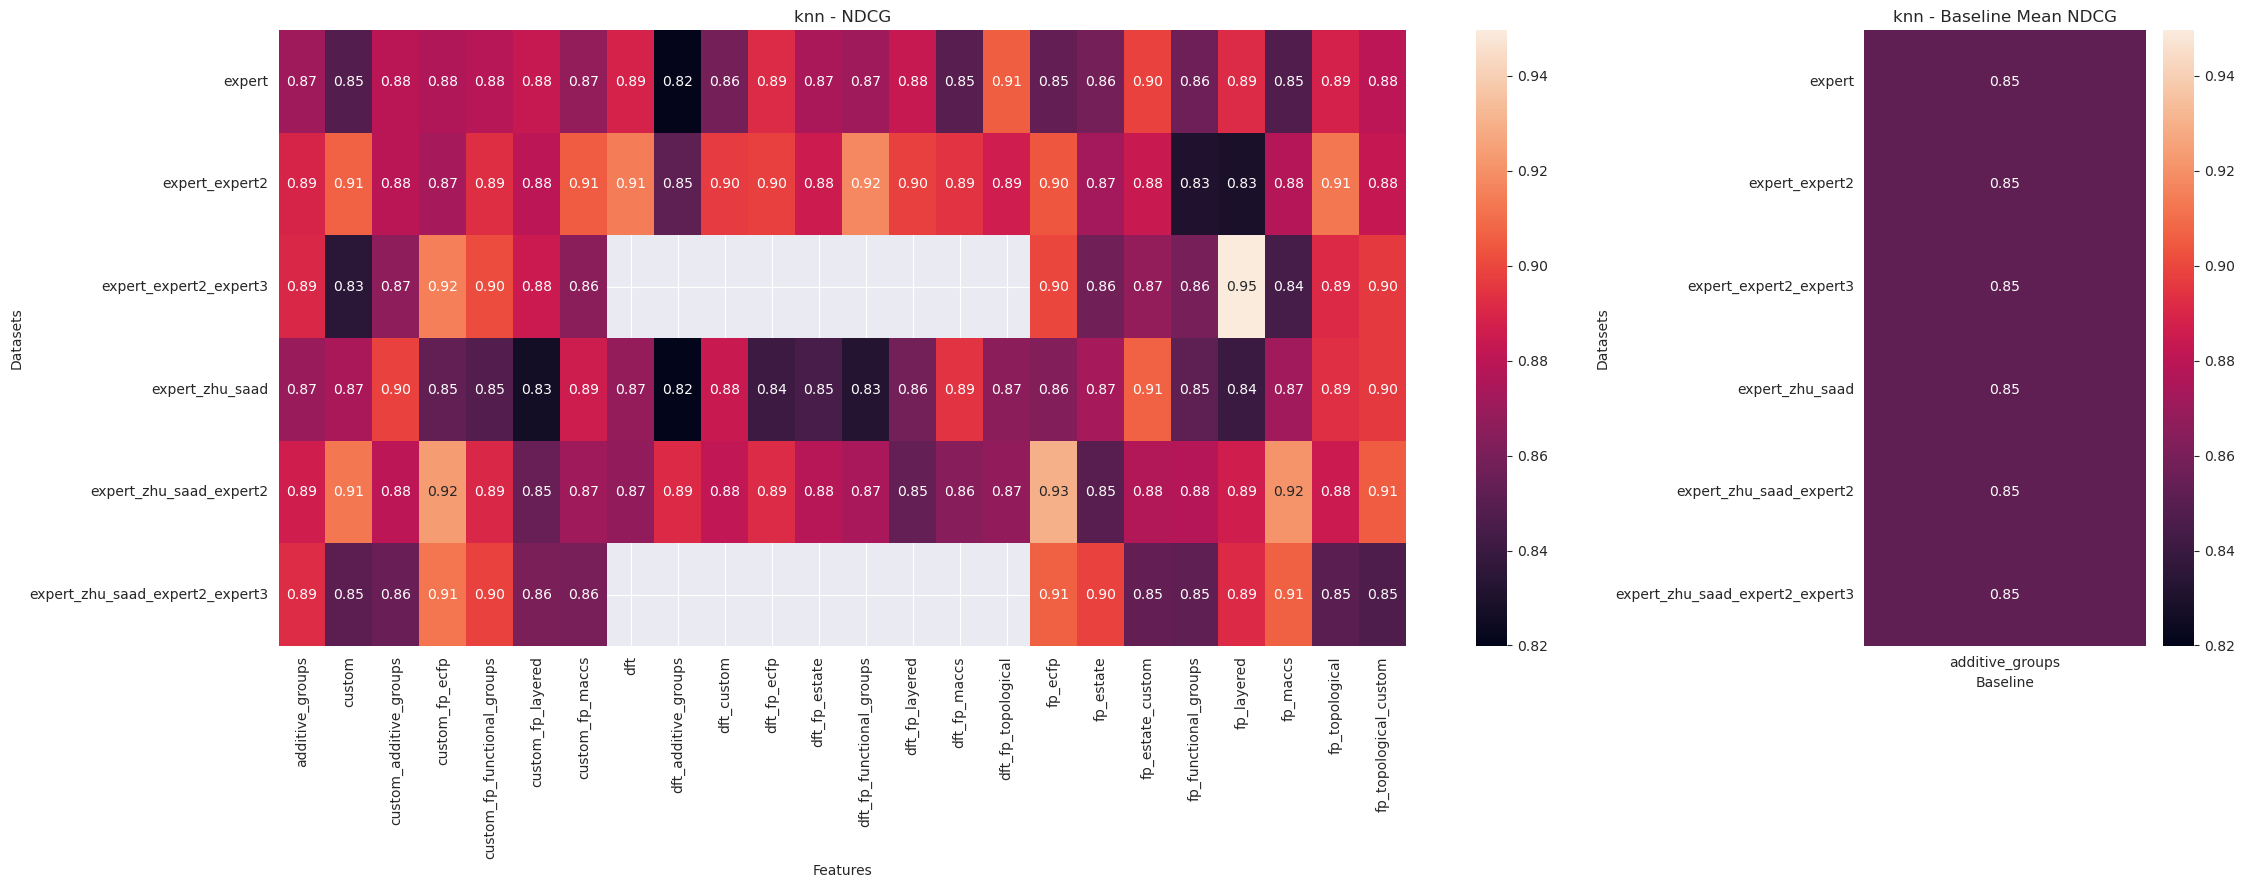

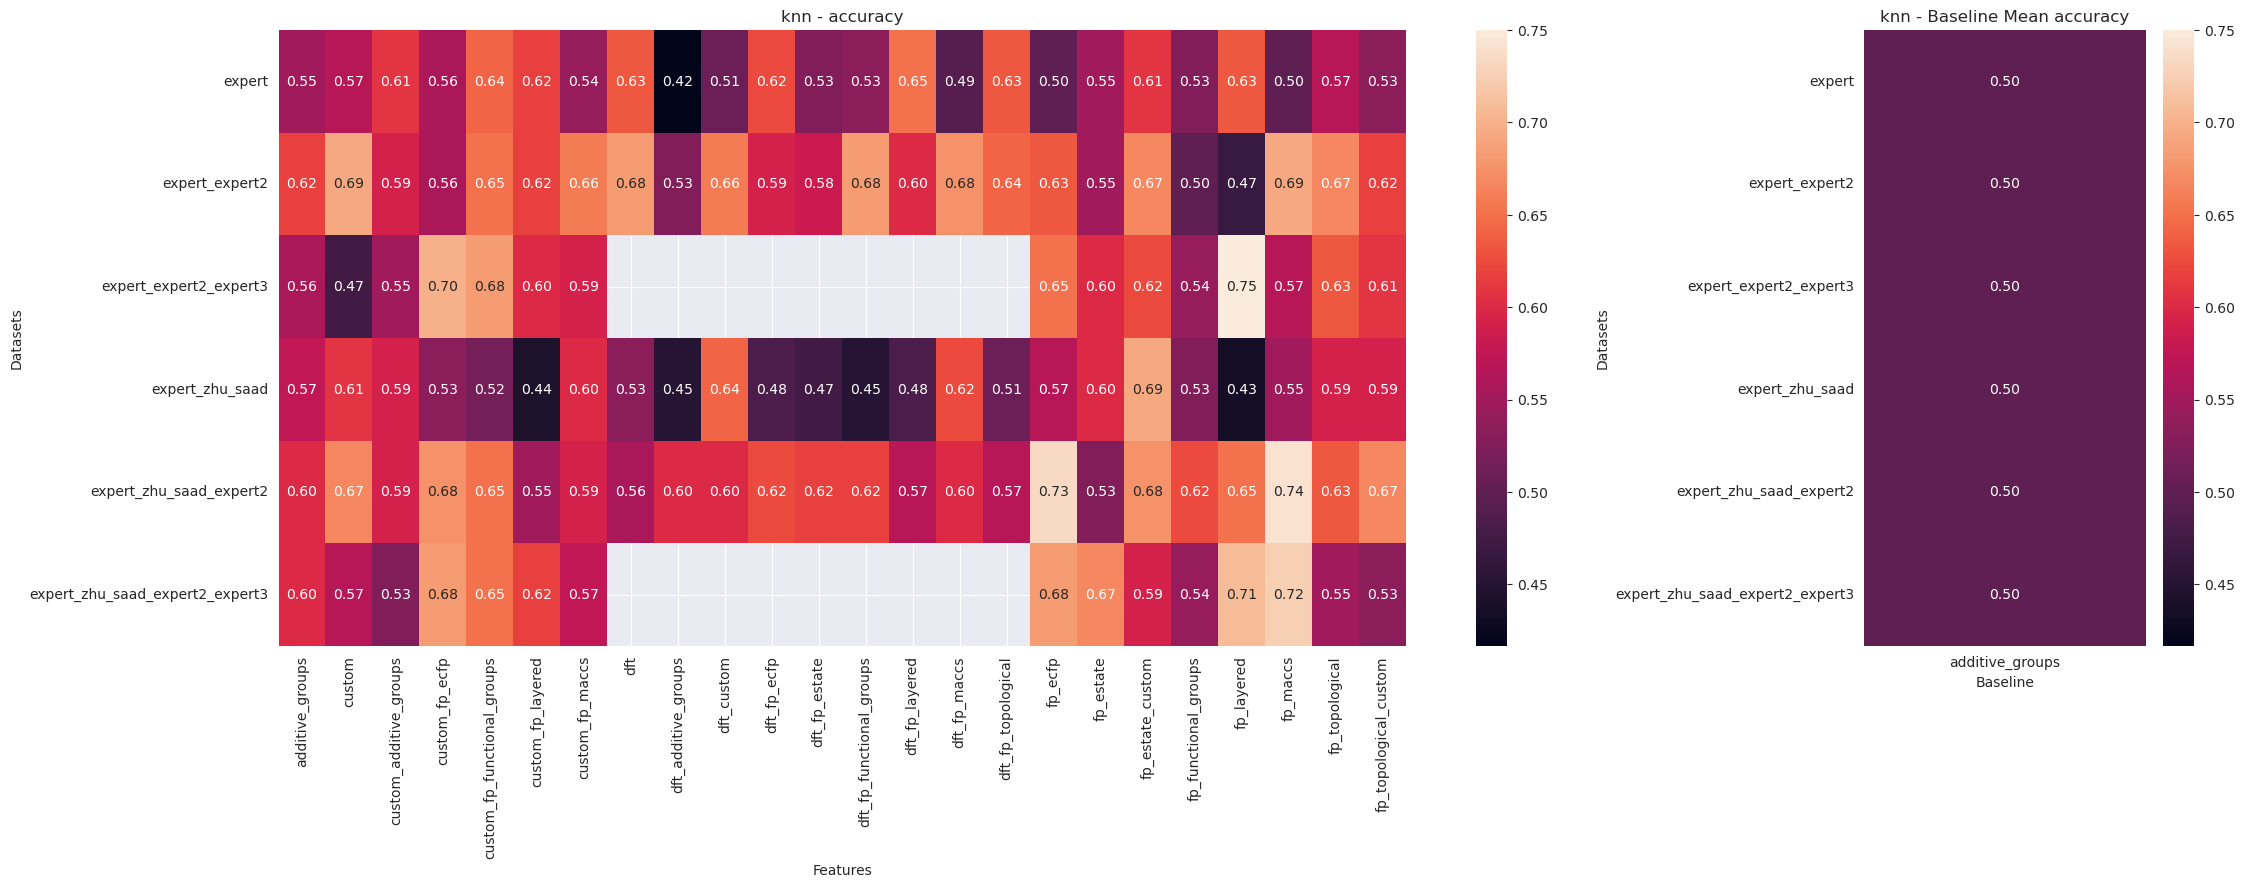

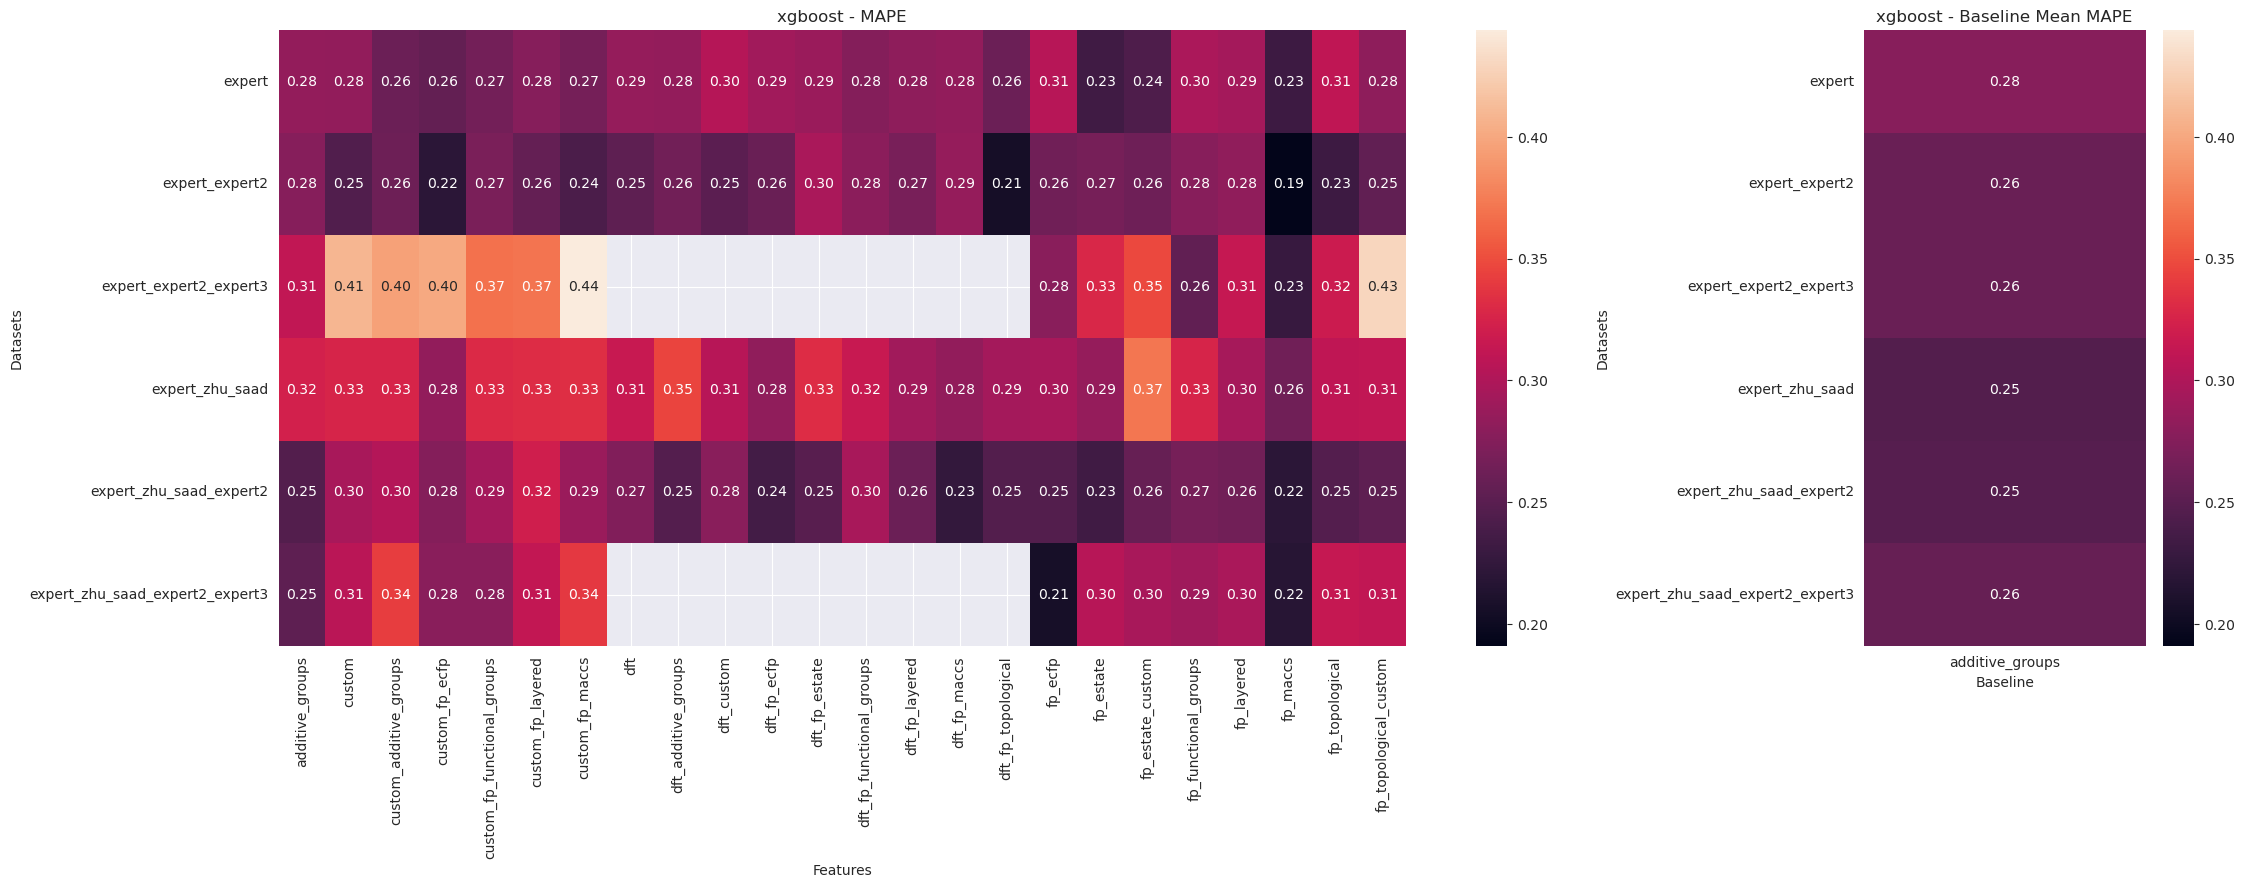

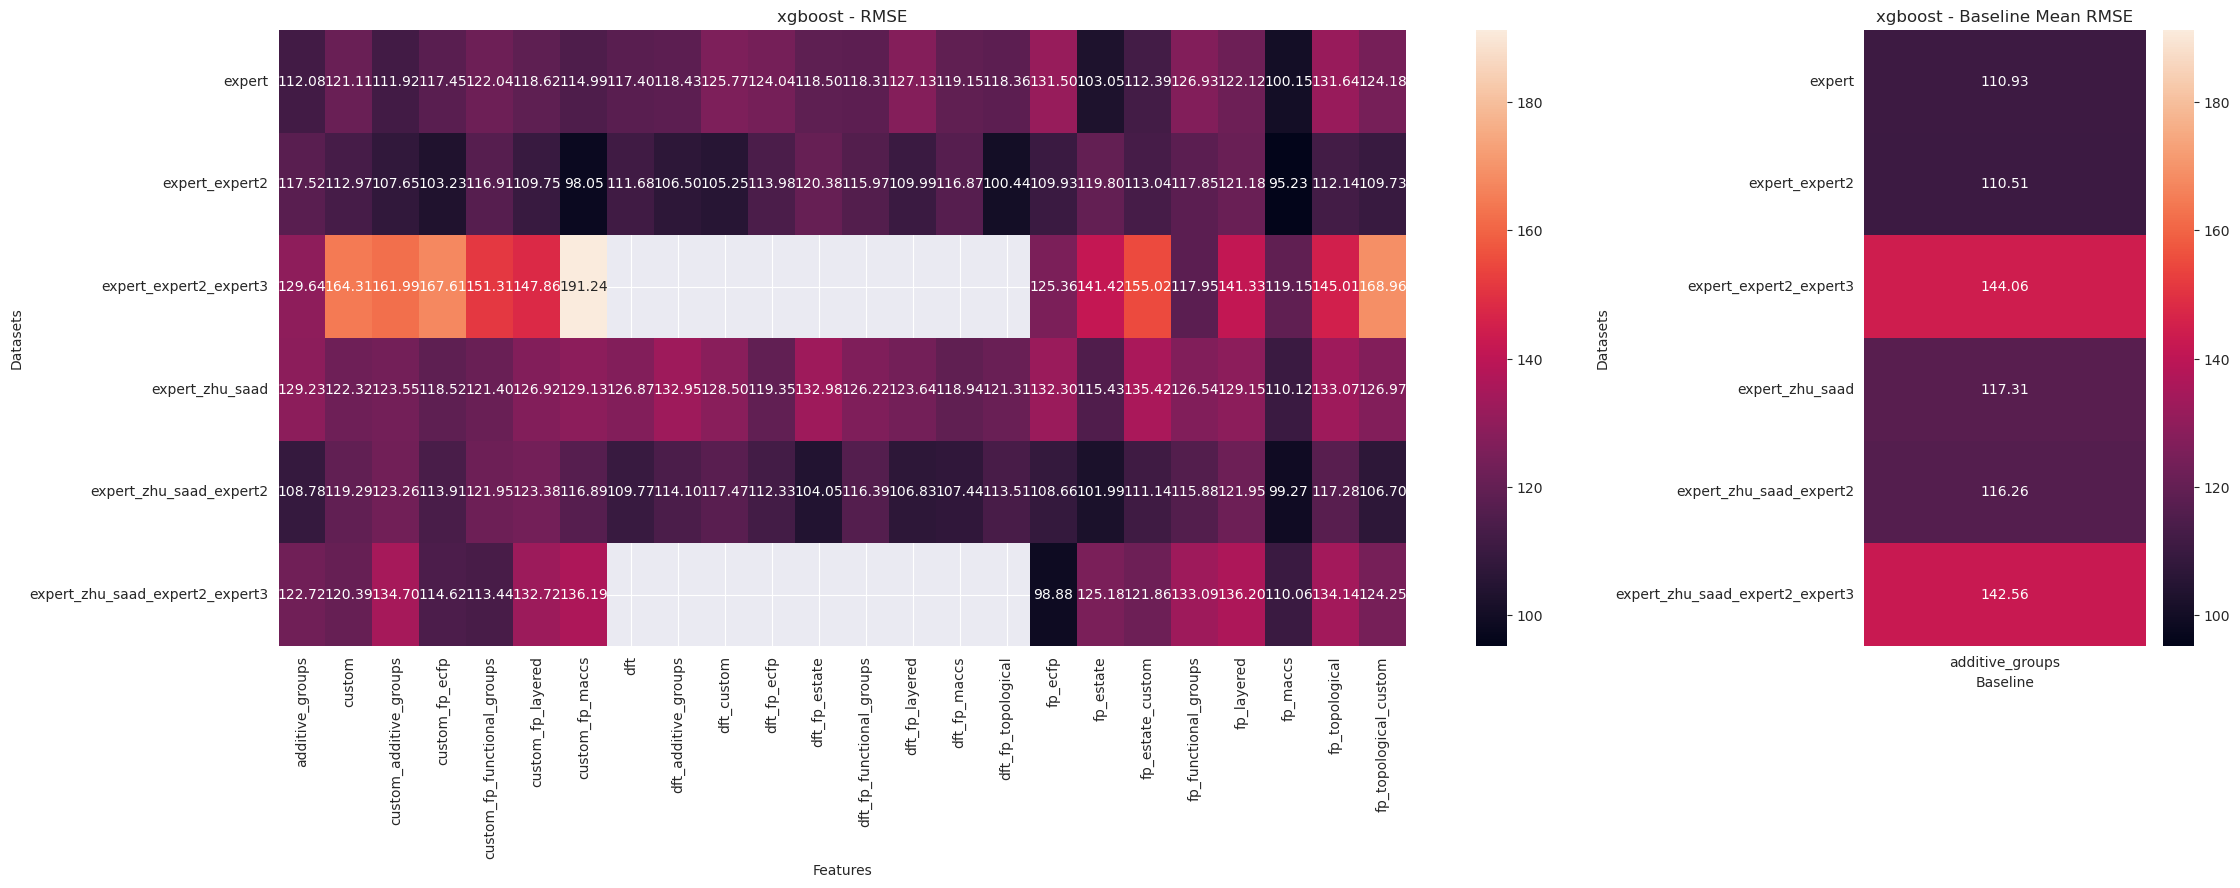

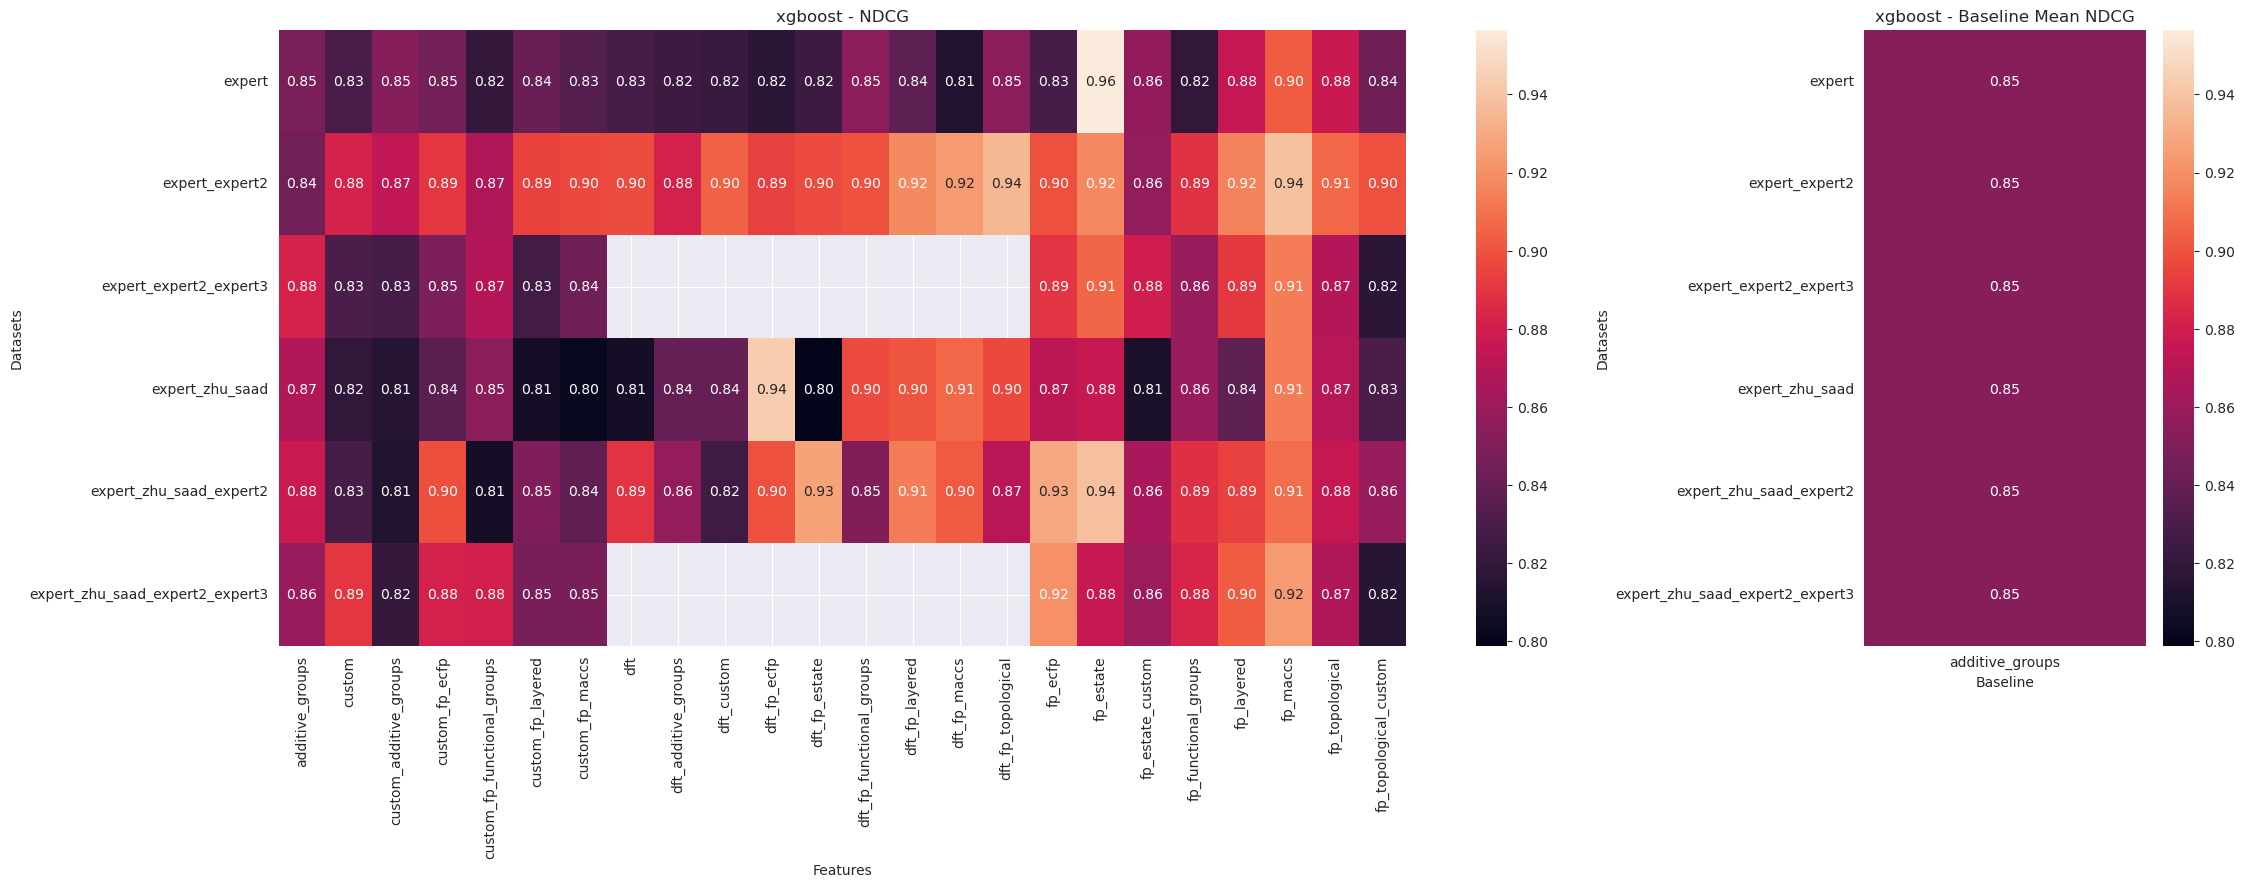

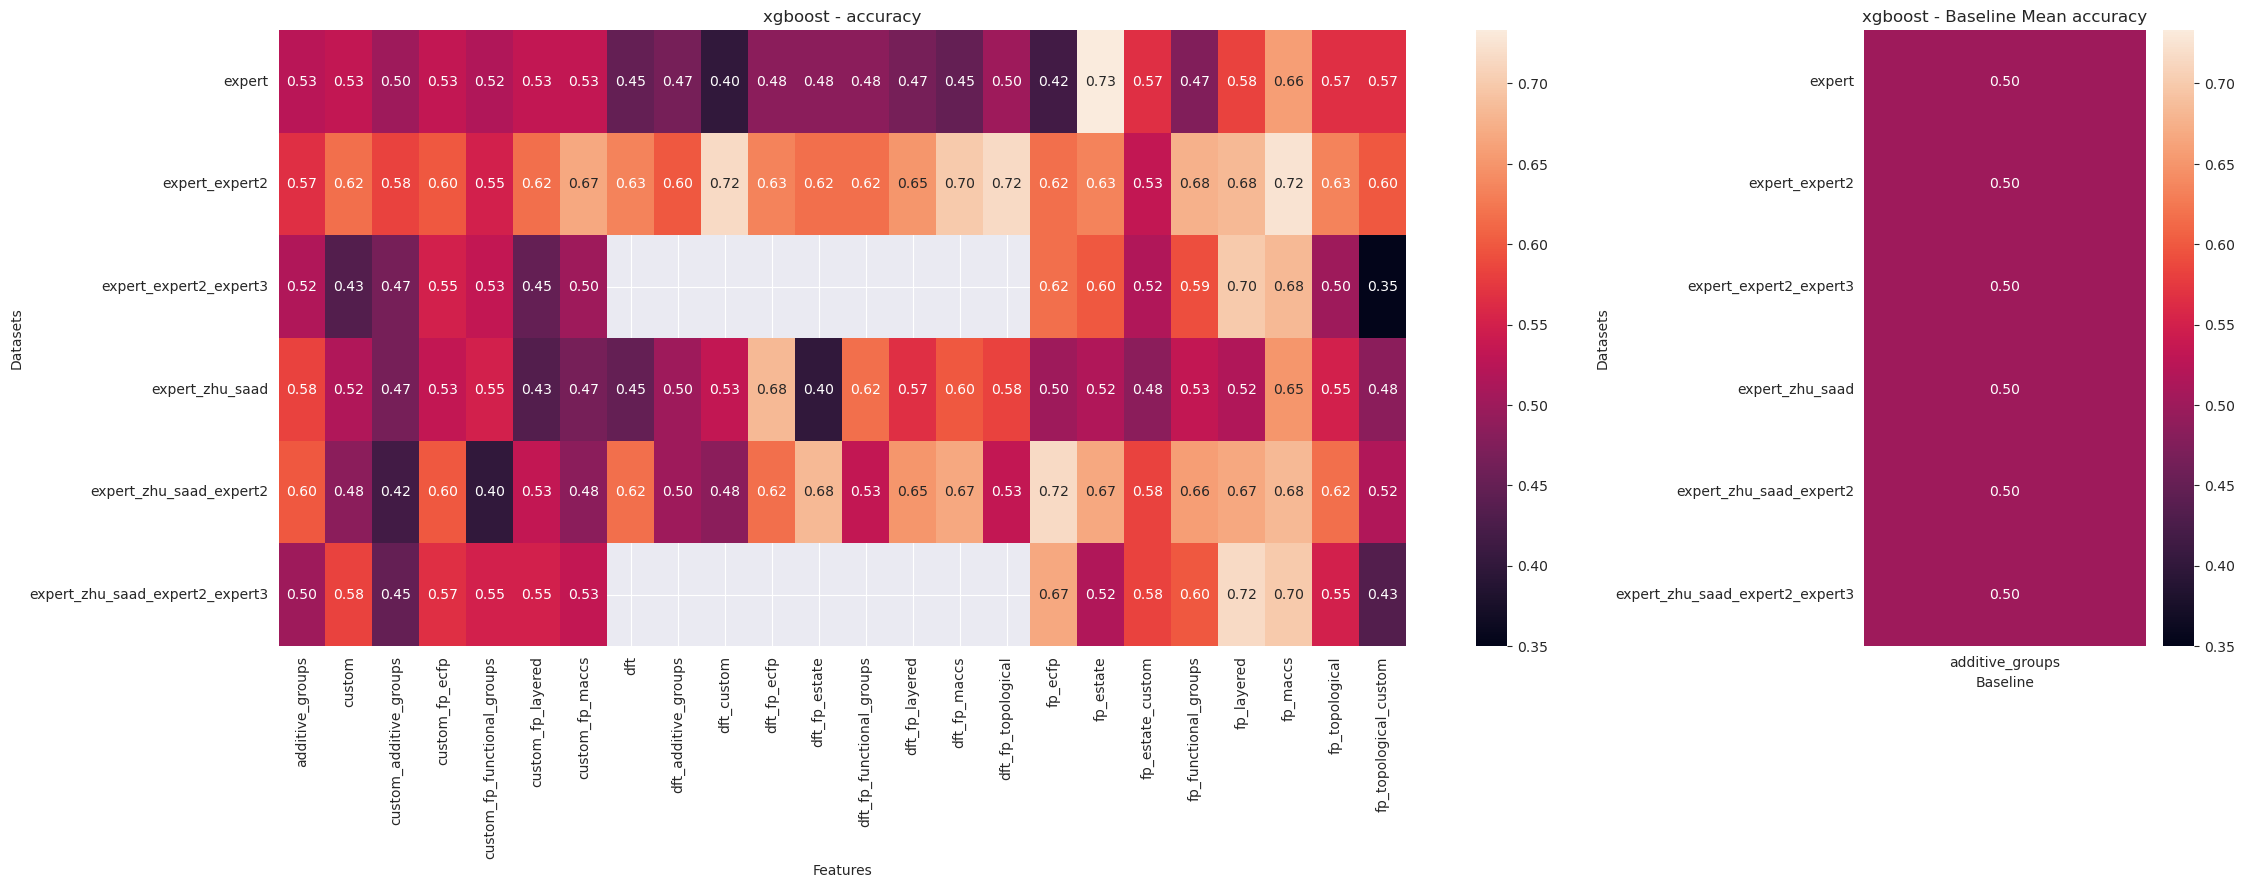

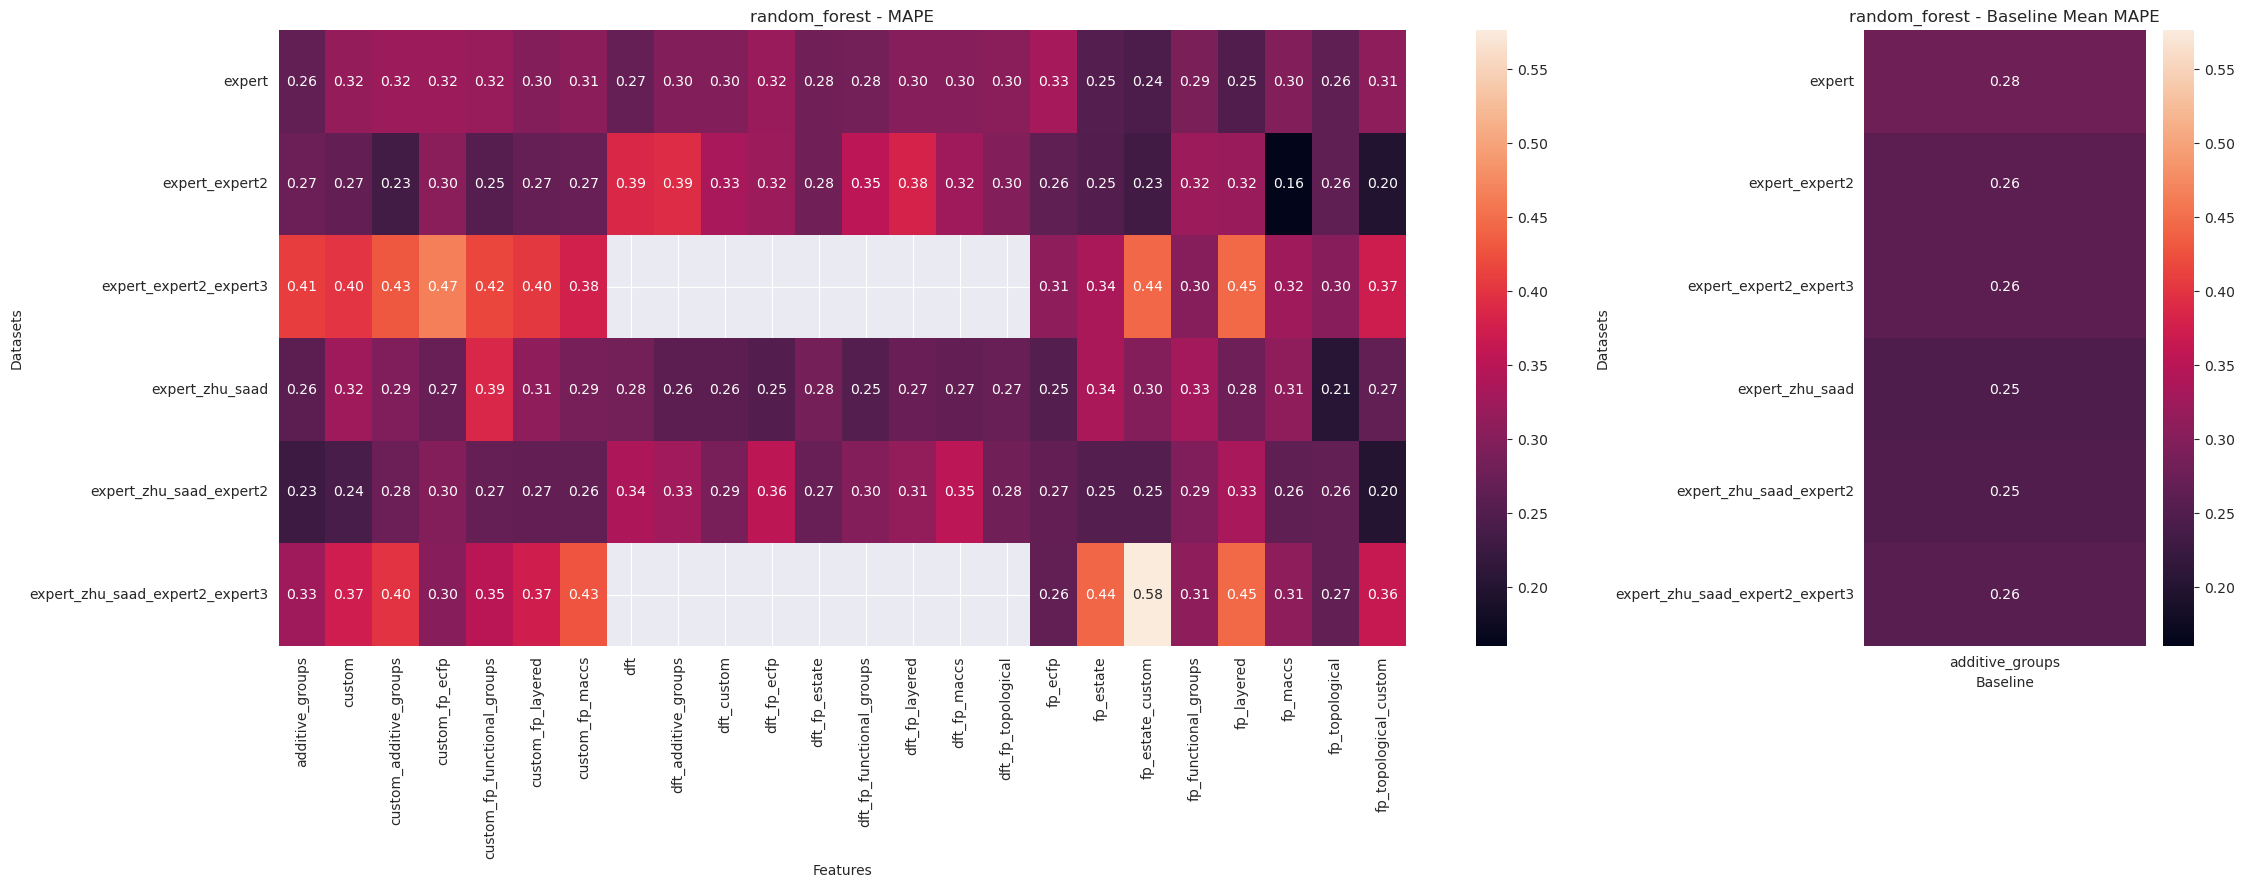

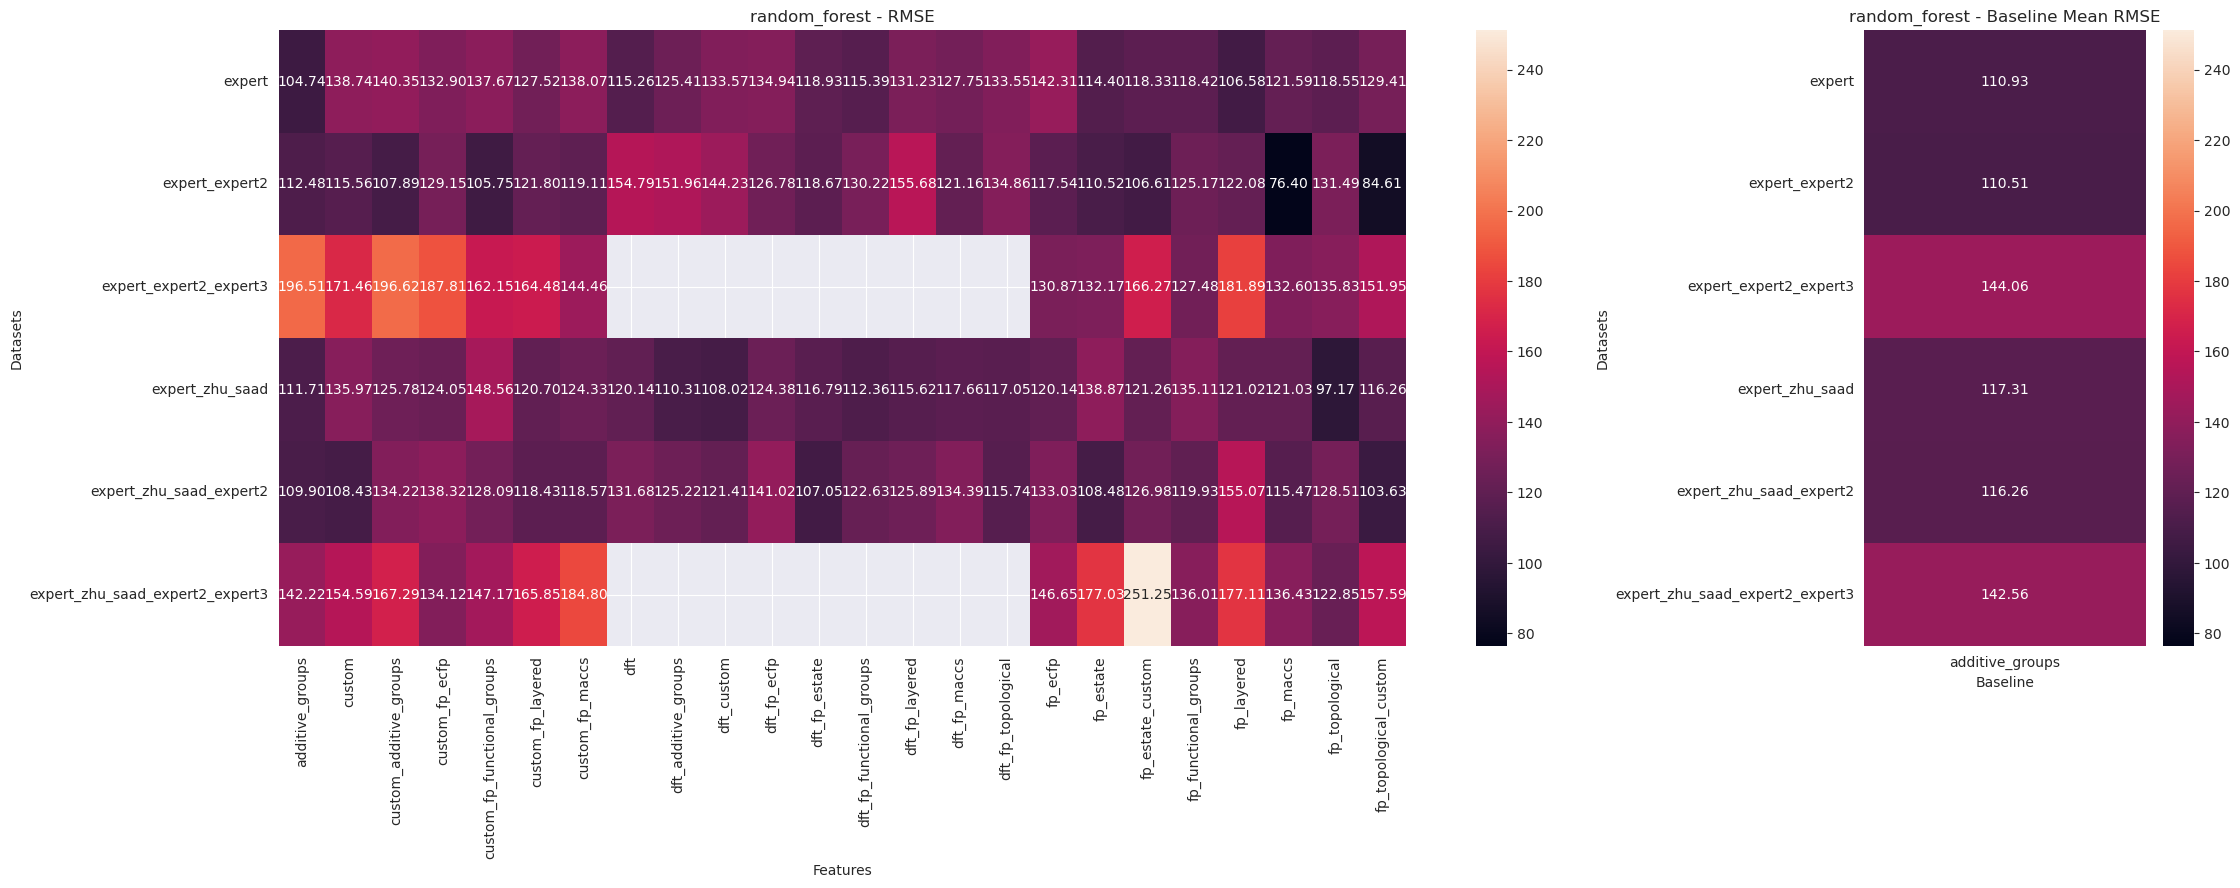

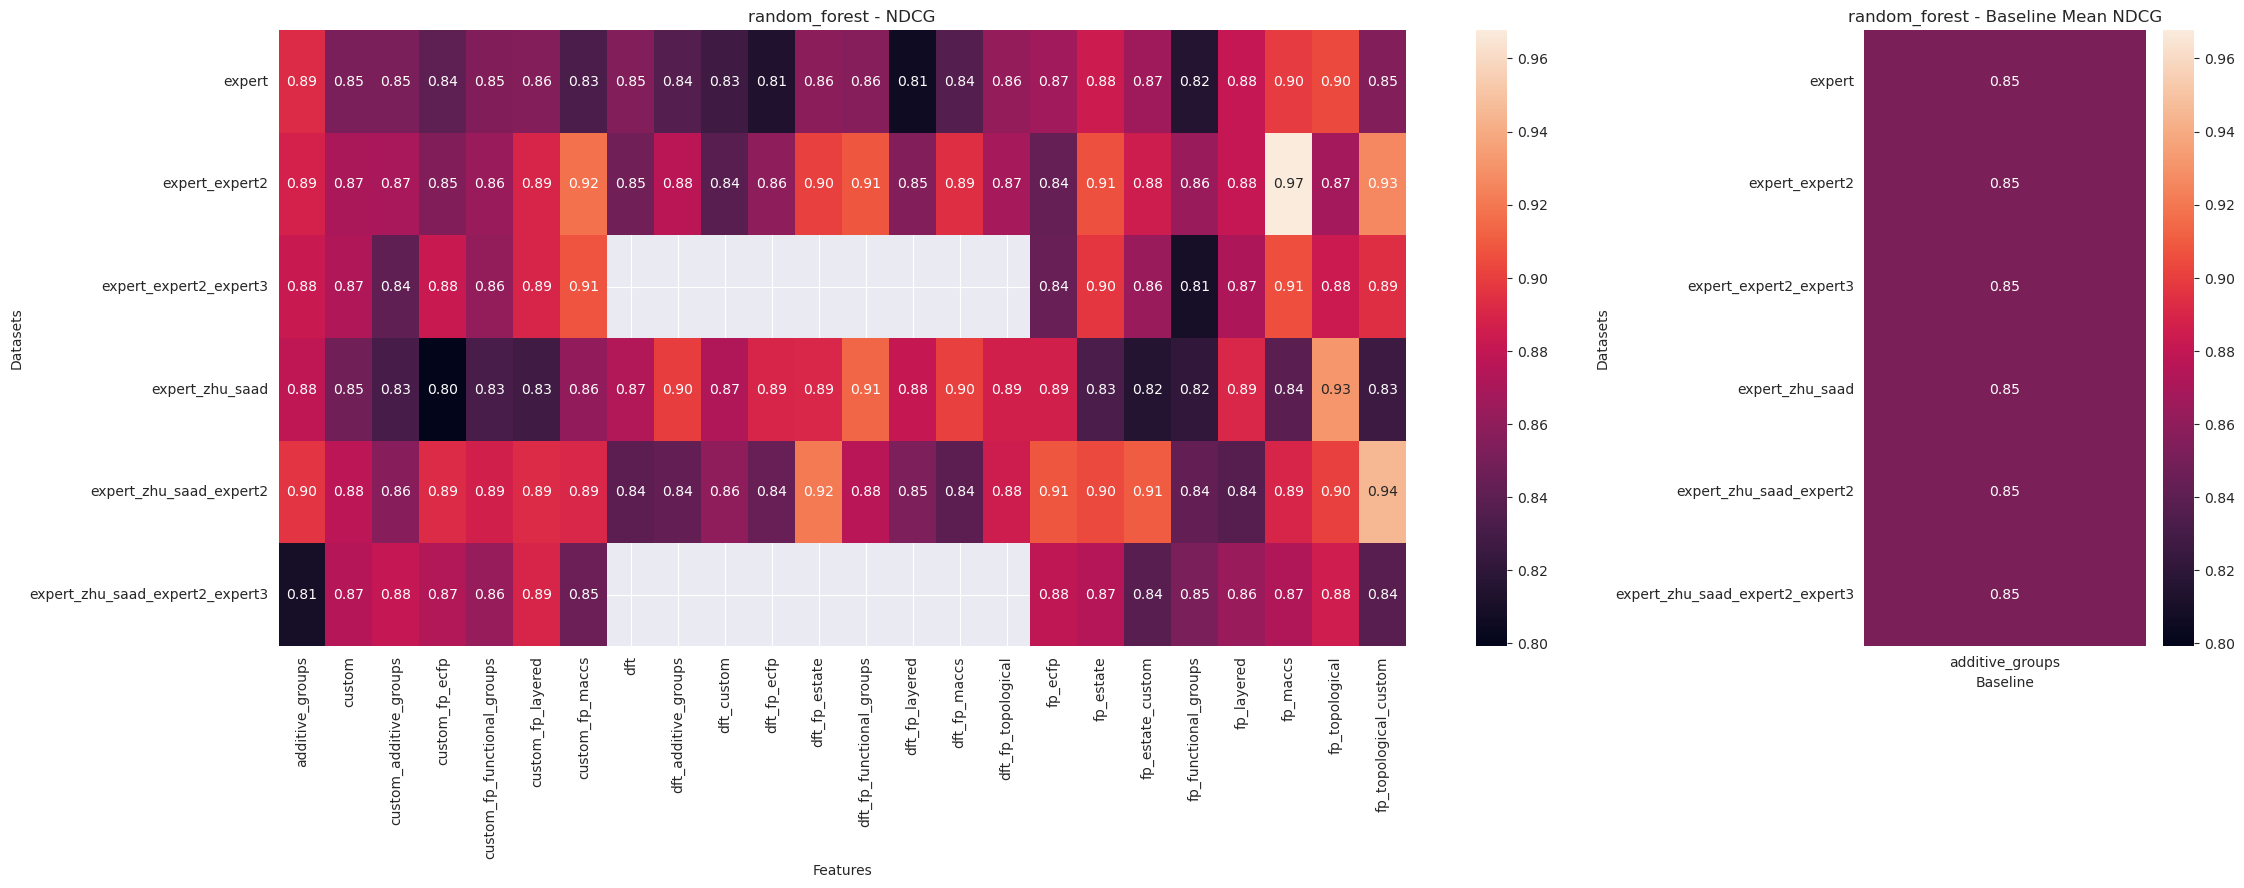

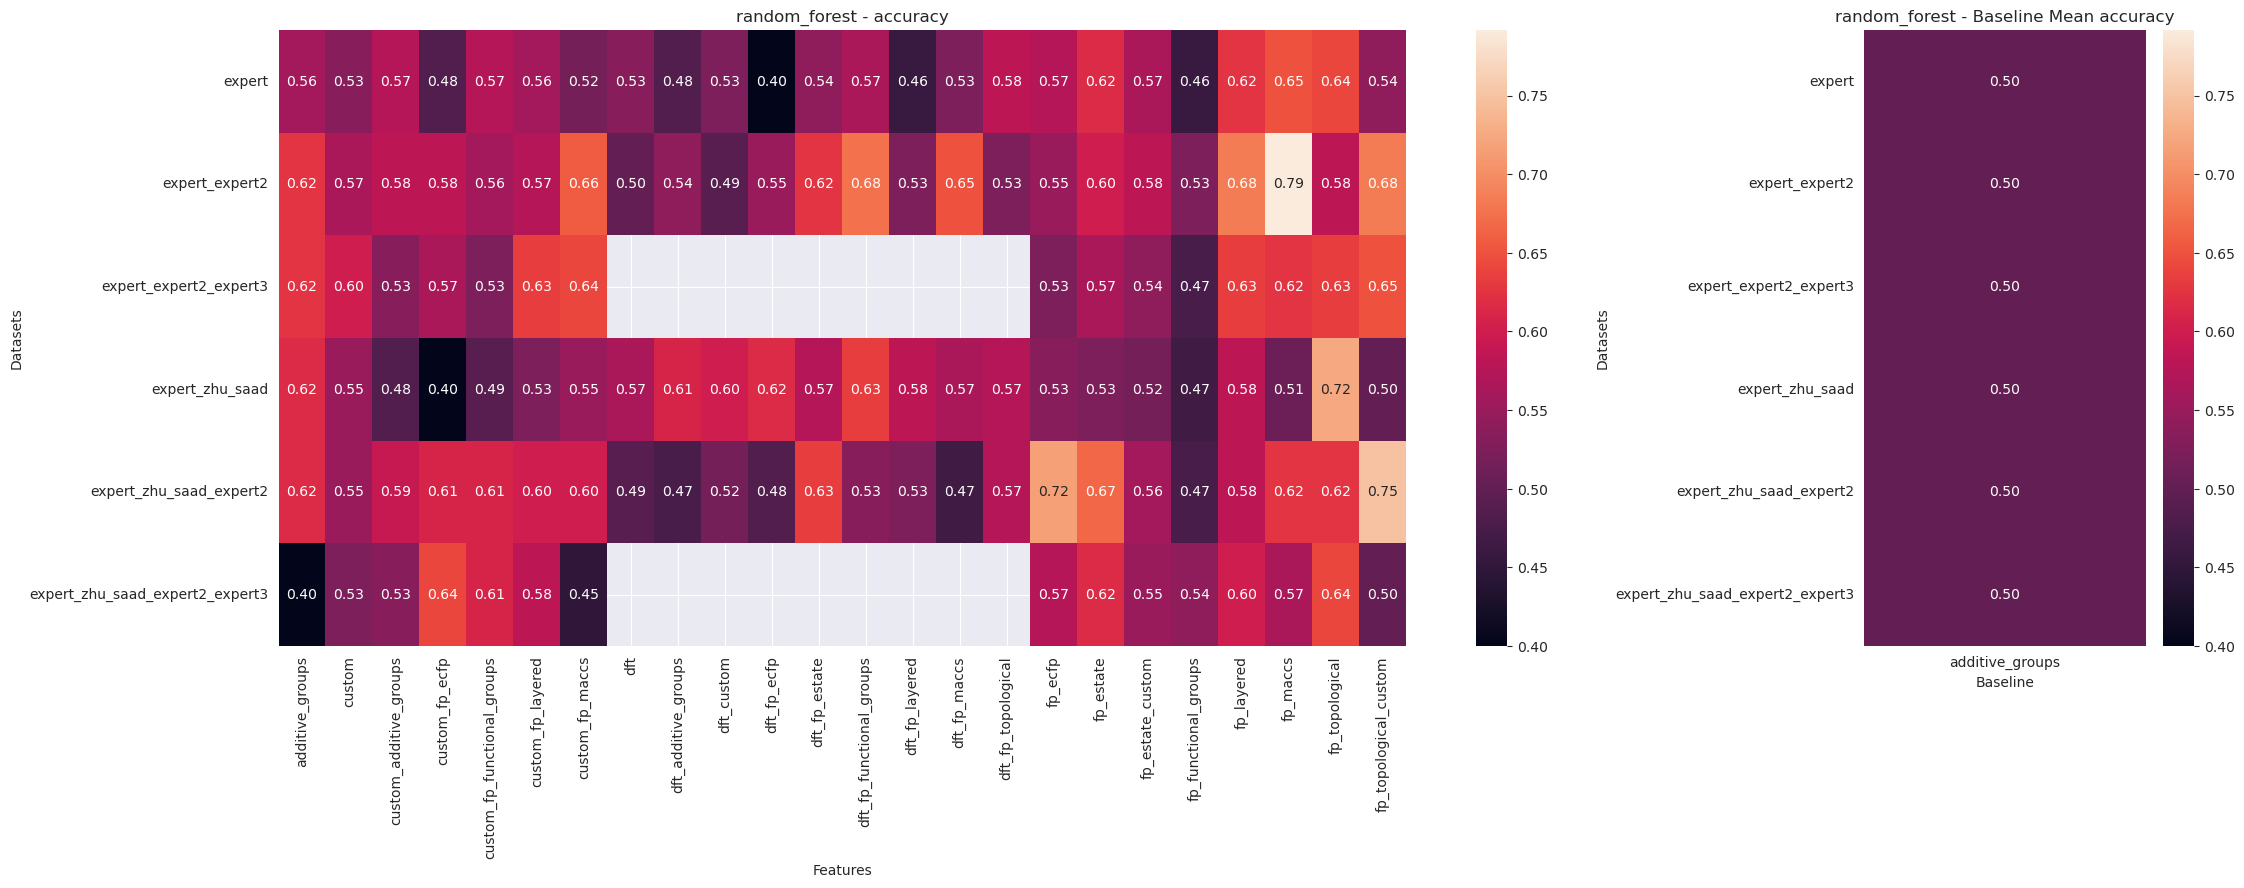

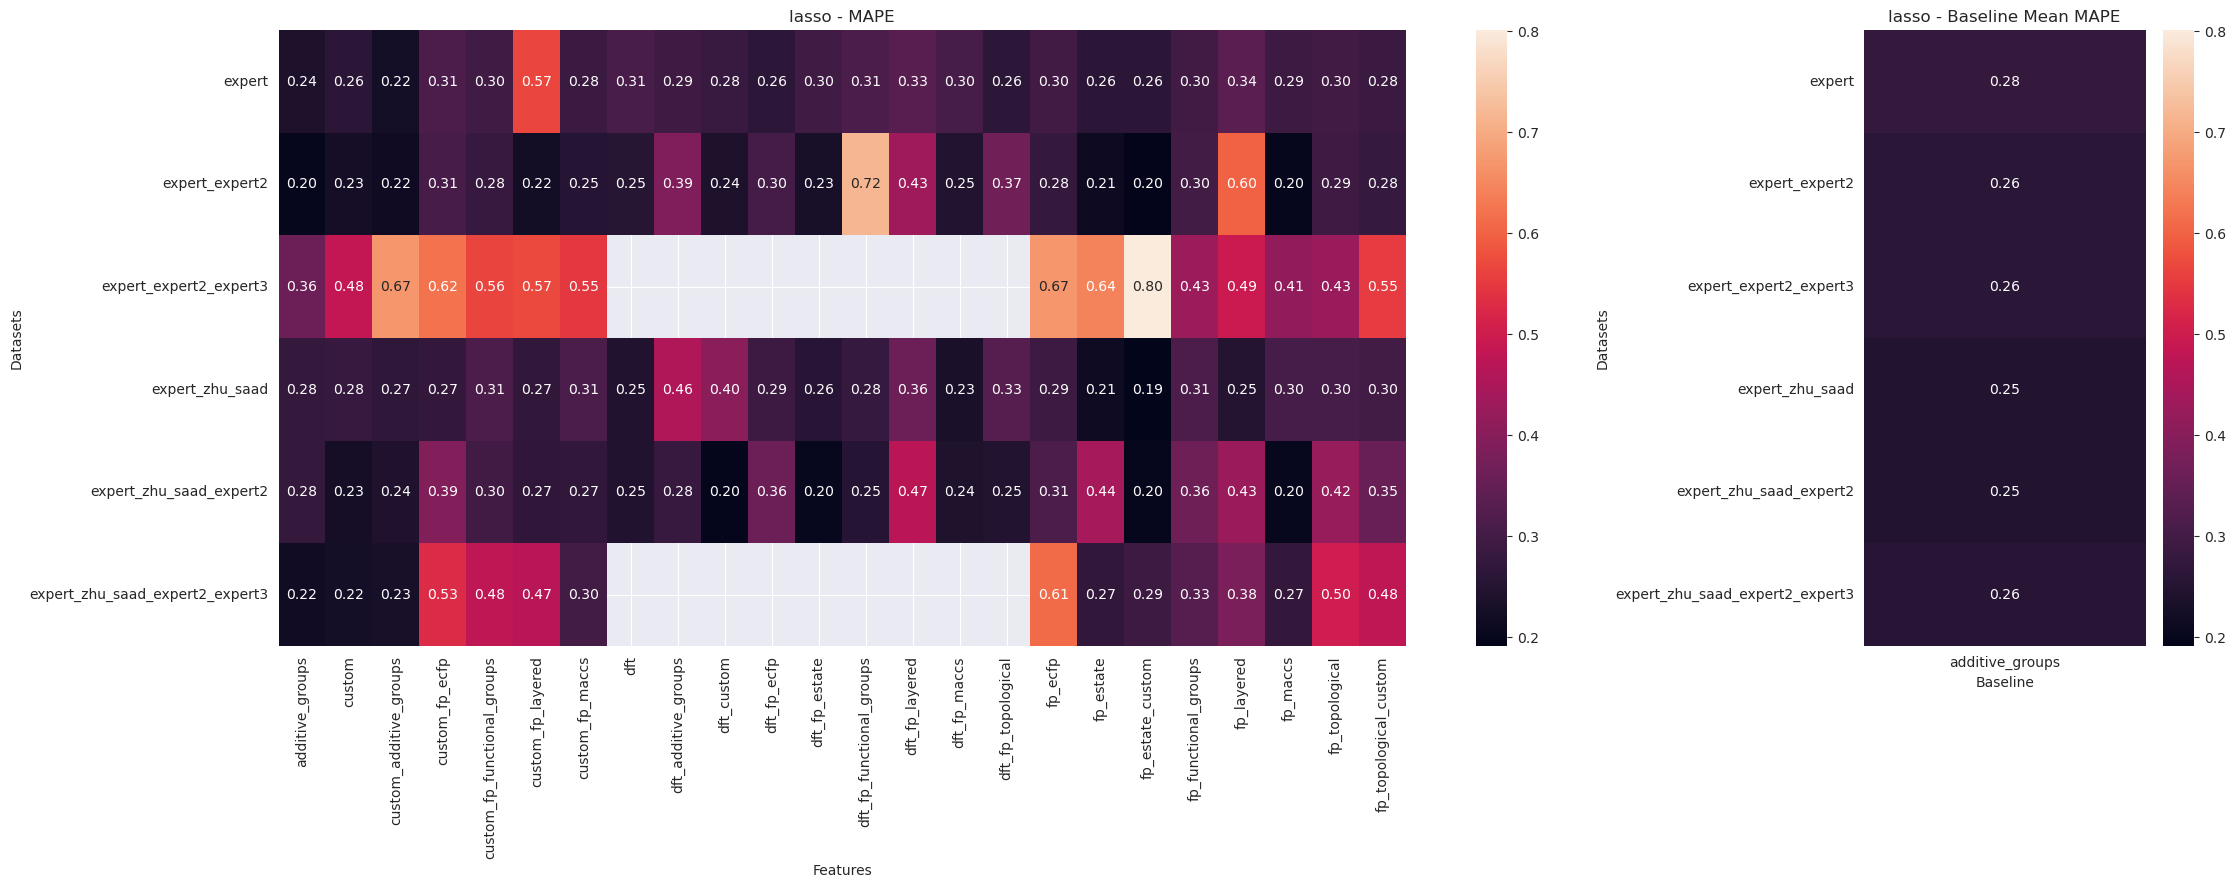

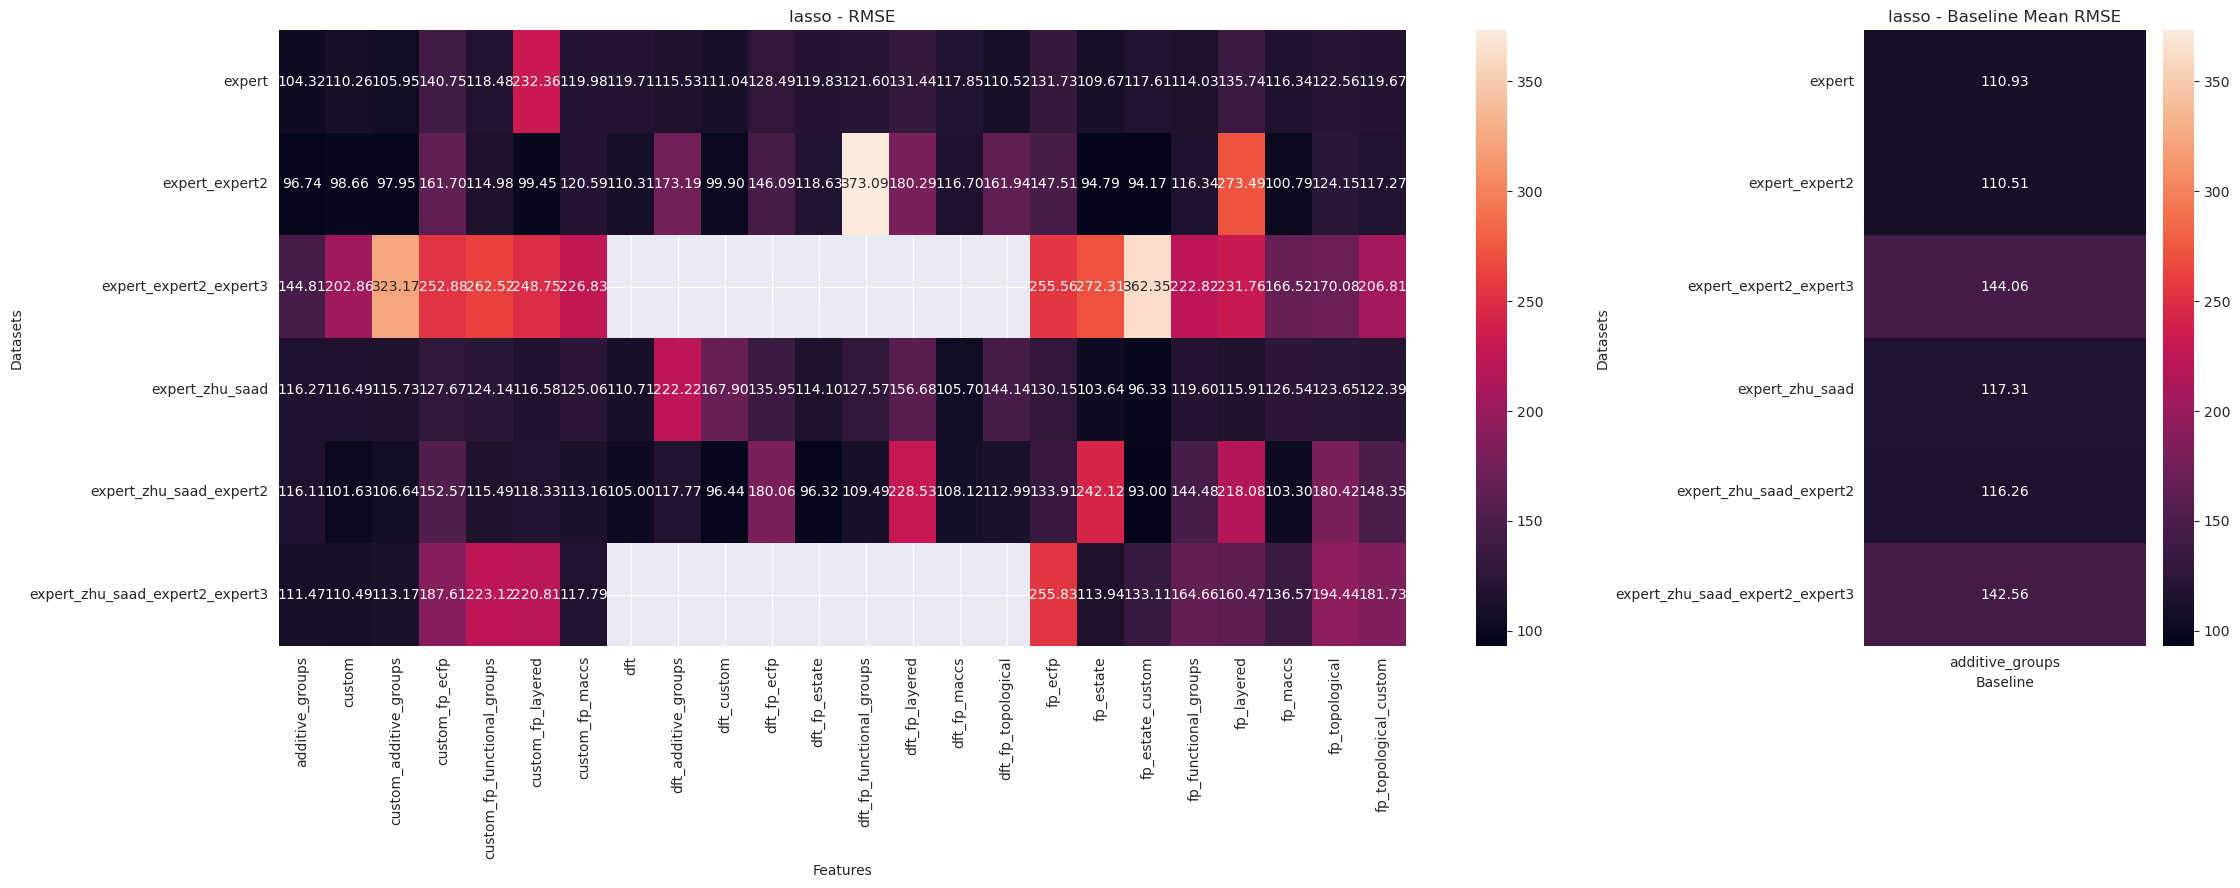

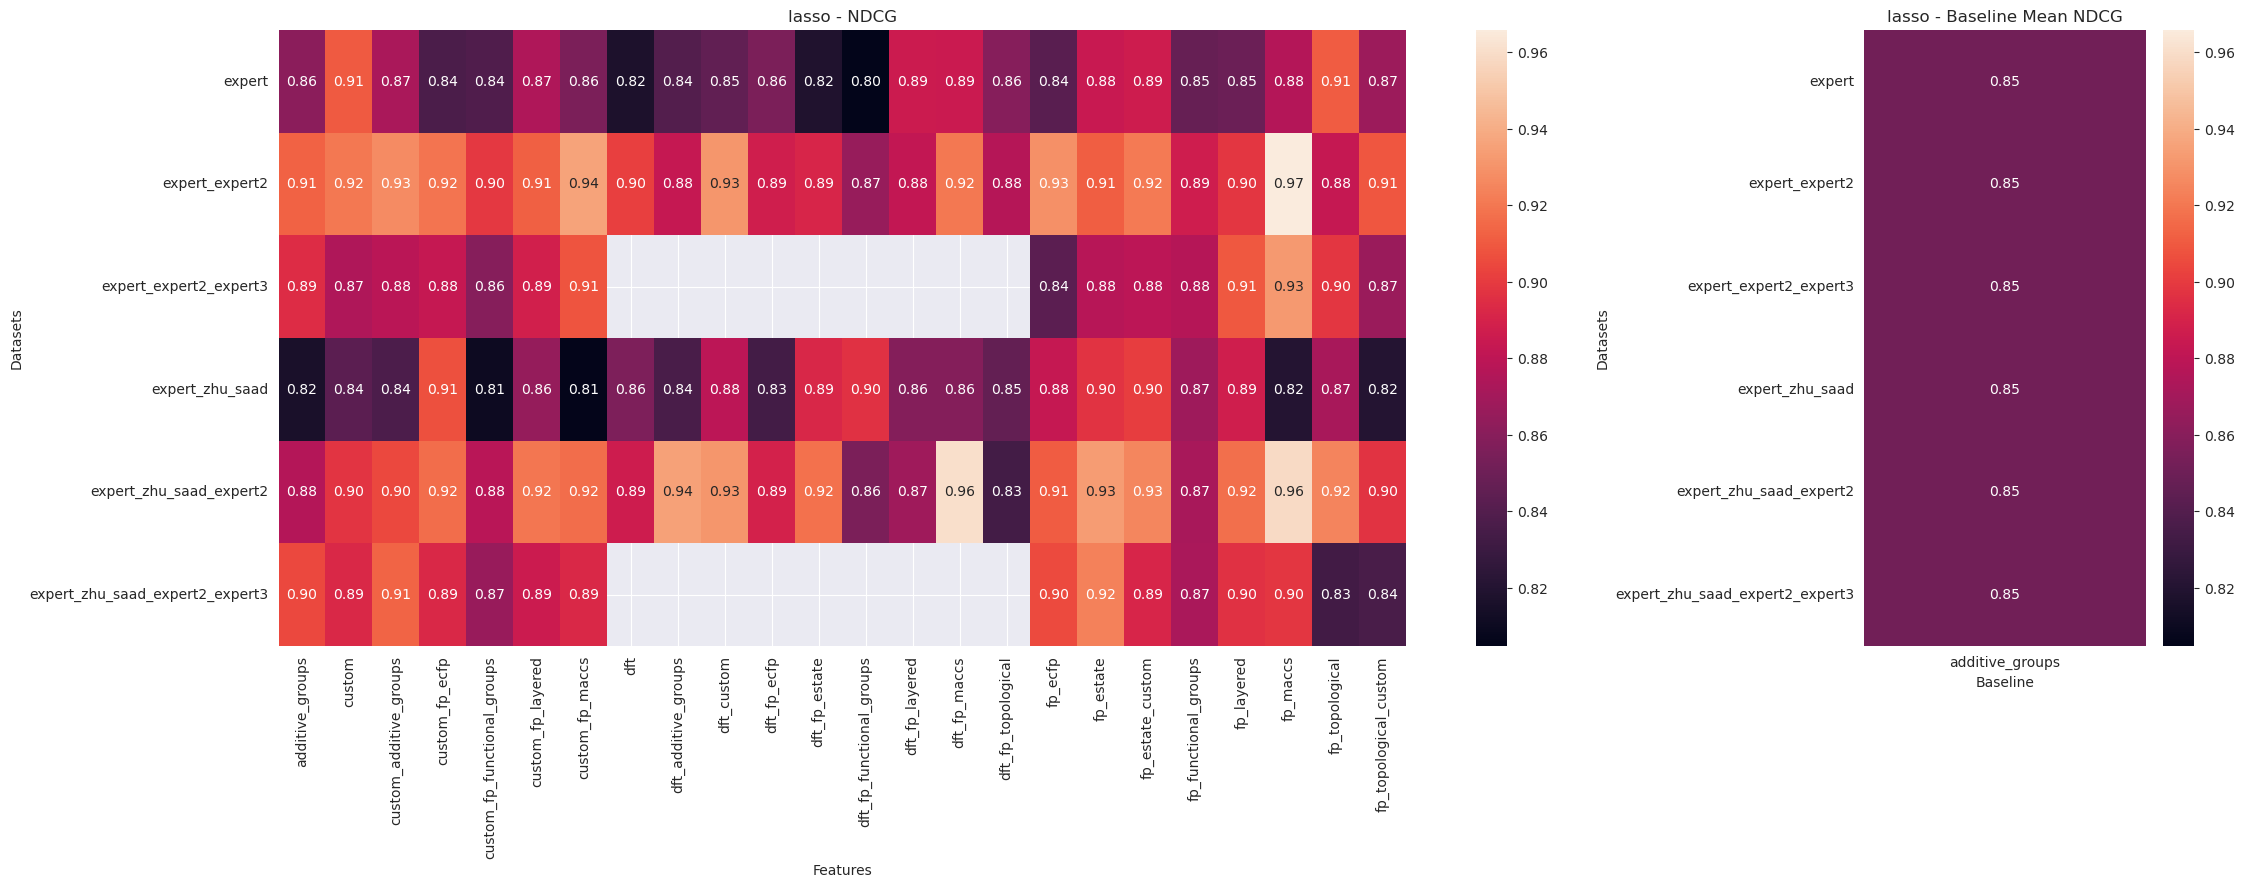

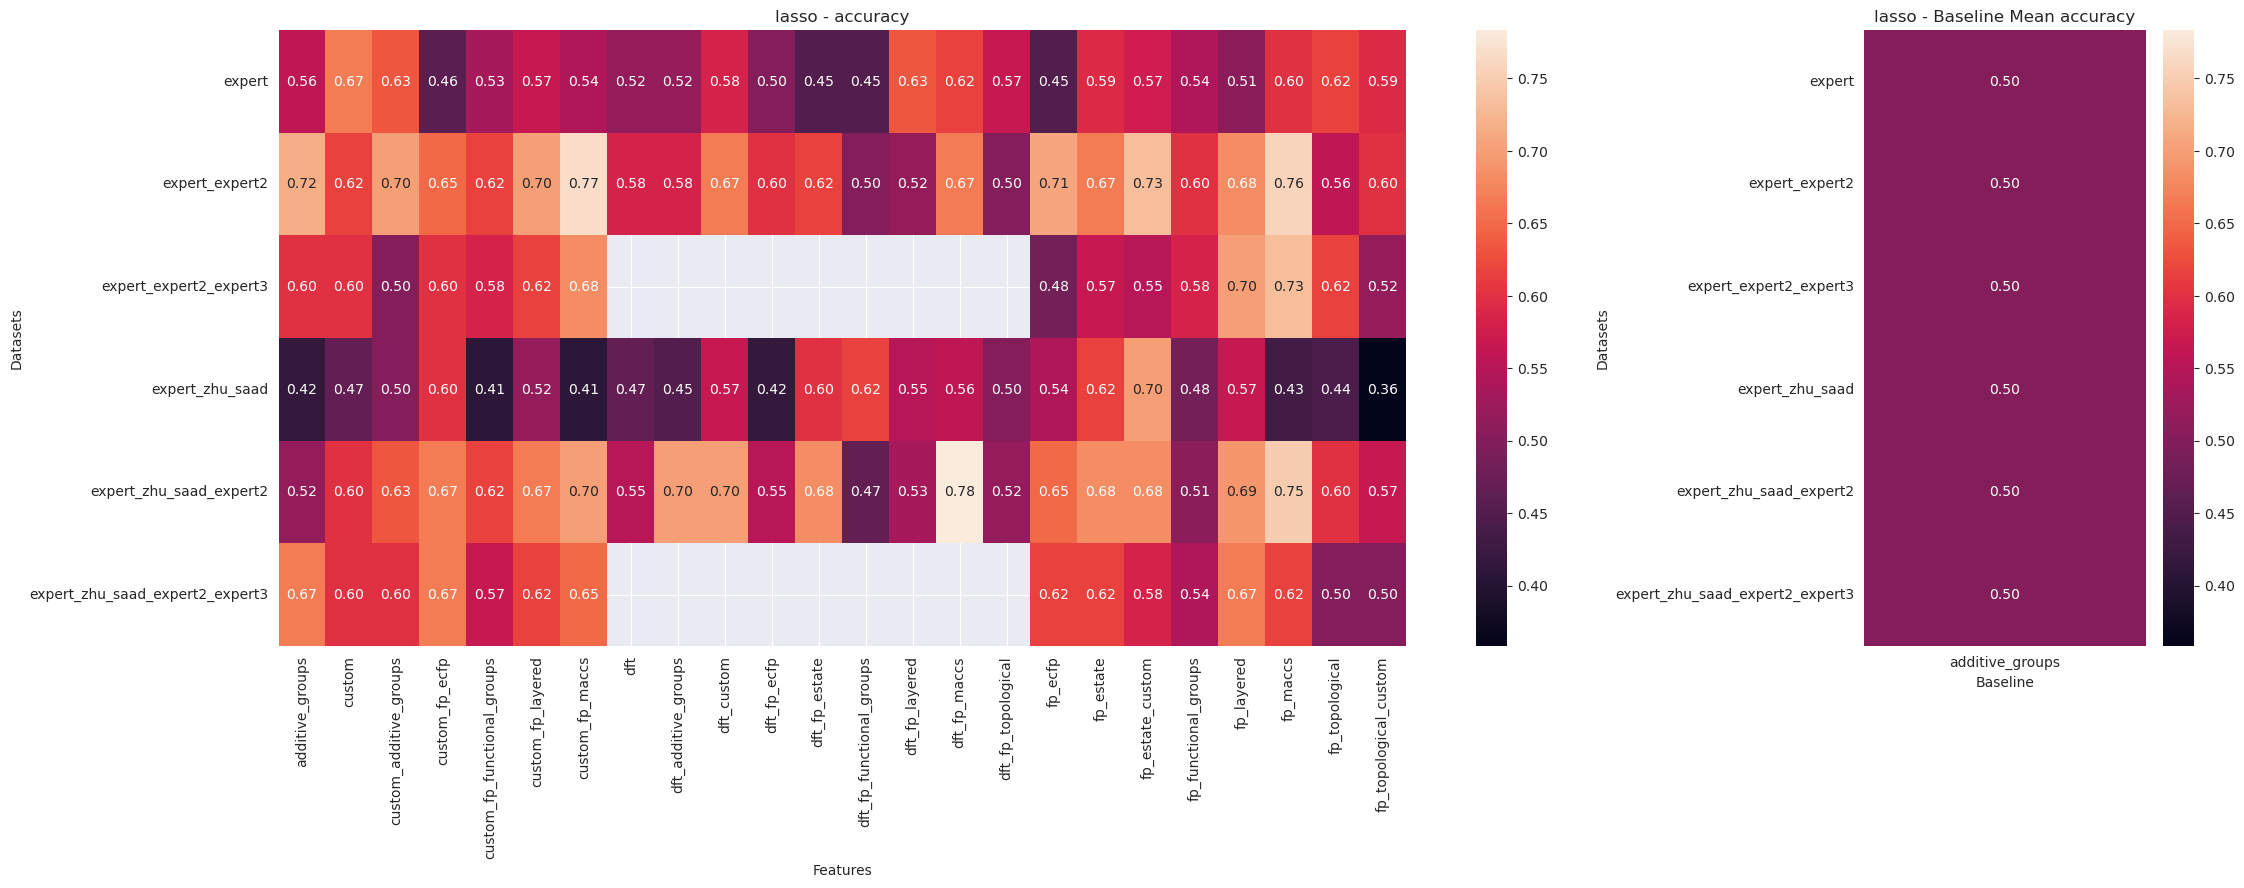

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the transformed CSV file
df = pd.read_csv('../../../results/comparison/all_datasets_all_features.csv')
#df = pd.read_csv('../../../results/transformed_comparison_matrix_custom_dft.csv')
#df = pd.concat([df1, df2]).reset_index().drop(['index'], axis=1)
display(df.head())

# List of classifiers and metrics
classifiers = ['knn', 'xgboost', 'random_forest', 'lasso']
metrics = ['MAPE', 'RMSE', 'NDCG', 'accuracy']

# Create a grid for each classifier and metric
for clf in classifiers:
    for metric in metrics:
        # Pivot the data to get features on x-axis and datasets on y-axis
        pivot_table_rmse = df[df['model'] == clf].pivot(index='datasets', columns='features', values=metric)
        pivot_table_baseline = df[df['model'] == clf].pivot(index='datasets', columns='features', values=f'baseline_mean_{metric}')
        baseline_column = pivot_table_baseline.iloc[:, 0]

        # Determine the color scale limits
        vmin = min(pivot_table_rmse.min().min(), pivot_table_baseline.min().min())
        vmax = max(pivot_table_rmse.max().max(), pivot_table_baseline.max().max())

        # Create subplots
        fig, axes = plt.subplots(1, 2, gridspec_kw={'width_ratios': [4, 1]}, figsize=(25,8))

        # Heatmap for RMSE
        sns.heatmap(pivot_table_rmse, annot=True, fmt=".2f",  ax=axes[0])
        axes[0].set_title(f'{clf} - {metric}')
        axes[0].set_xlabel('Features')
        axes[0].set_ylabel('Datasets')

        # Heatmap for Baseline Mean RMSE
        sns.heatmap(baseline_column.to_frame(), annot=True, fmt=".2f", vmin=vmin, vmax=vmax, ax=axes[1])
        axes[1].set_title(f'{clf} - Baseline Mean {metric}')
        axes[1].set_xlabel('Baseline')
        axes[1].set_ylabel('Datasets')

        # Show the plots
        plt.show()